# XGBOOST

In [ ]:
# import potrebnych kniznic a konfiguracia notebooku

import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from xgboost import XGBRegressor
import shap

import xgboost_functions
importlib.reload(xgboost_functions)
from xgboost_functions import make_features, extract_tree_structure, trace_path_for_observation, rolling_forecast_xgb

import cred
from cred import DATA_PATH_CRED

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit

plt.rcParams.update({
    "figure.figsize": (13, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


print("Importy uspesne.")


C:\Users\adamv\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importy uspesne.


In [ ]:
# konfiguracia a stiahnutie dat
main_dir = Path(DATA_PATH_CRED)
data_mod = "data_mod.csv"
pp_orig = "data.xlsx"
DATA_PATH_DATA_MOD  = main_dir / data_mod
DATA_PATH_DATA = main_dir / pp_orig
SHEET_NAME_PP = "pp"
SHEET_NAME_EXOG = "exog"
TEST_SIZE = 24
RANDOM_STATE = 24
TARGET_VAR = "pp_sa_ca_jd"

df_raw = pd.read_csv(DATA_PATH_DATA_MOD)
df_raw["datum"] = pd.to_datetime(df_raw["datum"])
df_raw = df_raw.set_index("datum").sort_index()
df_raw = df_raw.asfreq("MS")
df = df_raw.copy()

df_pp = pd.read_excel(DATA_PATH_DATA,SHEET_NAME_PP)
df_pp = df_pp.set_index("datum").sort_index()
df_pp = df_pp.asfreq("MS")

df_exog = pd.read_excel(DATA_PATH_DATA,SHEET_NAME_EXOG)
df_exog = df_exog.set_index("datum").sort_index()
df_exog = df_exog.asfreq("MS")
df_exog = df_exog.drop(columns=["datum"], errors="ignore")

In [3]:
#definovanie features, train/test vzorka
exog_cols = df.drop(columns=[TARGET_VAR,"pp_nonsa","pp_sa_orig" ])
features = make_features(
    data=df,
    target=TARGET_VAR,
    exog_cols=exog_cols,
    target_lags=(1, 2, 3, 6, 12),
    exog_lags=(1,)
)

X = features.drop(columns = [TARGET_VAR, "pp_sa_ca_jd_lag1"])
y = features[TARGET_VAR]

X_train, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_train, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]

print(f"Trenovacia mnozina: {y_train.index.min().date()} az {y_train.index.max().date()} ({len(y_train)} obs.)")
print(f"Testovacia mnozina: {y_test.index.min().date()} az {y_test.index.max().date()} ({len(y_test)} obs.)")


Trenovacia mnozina: 2001-02-01 az 2023-12-01 (275 obs.)
Testovacia mnozina: 2024-01-01 az 2025-12-01 (24 obs.)


In [4]:
#tuning hyperparametrov
tscv = TimeSeriesSplit(n_splits=5)

#random_search
random_param_space = {
    "n_estimators": [100, 200, 300, 400, 600],
    "max_depth": [1, 2, 3, 4, 5, 6],
    "learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 1.5, 2],
    "gamma": [0, 0.1, 0.5, 1, 5],
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE),
    param_distributions=random_param_space,
    n_iter=60,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

random_search.fit(X_train, y_train)
print("Najlepsie parametre z Random Search:", random_search.best_params_)

best = random_search.best_params_

#grid_search
grid_param_space = {
    "n_estimators": sorted(set([max(50, best["n_estimators"] - 100), best["n_estimators"], best["n_estimators"] + 100])),
    "max_depth": sorted(set([max(1, best["max_depth"] - 1), best["max_depth"], best["max_depth"] + 1])),
    "learning_rate": sorted(set([round(best["learning_rate"] * 0.5, 4), best["learning_rate"], round(best["learning_rate"] * 1.5, 4)])),
    "gamma": sorted(set([max(0, best["gamma"] - 1), best["gamma"], best["gamma"] + 1])),
    "subsample": [best["subsample"]],
    "colsample_bytree": [best["colsample_bytree"]],
    "min_child_weight": [best["min_child_weight"]],
    "reg_alpha": [best["reg_alpha"]],
    "reg_lambda": [best["reg_lambda"]],
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE),
    param_grid=grid_param_space,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print("Finalne parametre po Grid Search:", best_params)

Najlepsie parametre z Random Search: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.005, 'gamma': 1, 'colsample_bytree': 0.7}
Finalne parametre po Grid Search: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.0025, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 300, 'reg_alpha': 0.01, 'reg_lambda': 1, 'subsample': 0.6}


In [5]:
cv_results = pd.DataFrame(grid_search.cv_results_)

depth_summary = (
    cv_results
    .groupby("param_max_depth")
    .agg(
        best_rmse=("mean_test_score", lambda x: -x.max()),
        mean_rmse=("mean_test_score", lambda x: -x.mean()),
        std_cv=("std_test_score", "mean"),
        n_models=("mean_test_score", "count")
    )
    .reset_index()
    .sort_values("best_rmse")
)

depth_summary

,param_max_depth,best_rmse,mean_rmse,std_cv,n_models
2,5,3.728169,3.743703,1.082037,27
0,3,3.729493,3.751754,1.063940,27
1,4,3.729728,3.745369,1.075837,27


In [10]:
init_train_size = len(y) - TEST_SIZE
last_train_value = 102.154721
results, last_model = rolling_forecast_xgb(
    X=X,
    y_diff=y,
    level_series=df_pp[TARGET_VAR],        
    initial_train_size=init_train_size,
    last_train_value=last_train_value,
    horizon=1,
    refit_every=1,
    objective="reg:squarederror",
    xgb_params=best_params,
)

RMSE (diferencia): 2.5047
RMSE (level, onestep rekonstrukcia): 2.5047
MAPE (level, WMAPE = sum|chyba| / sum|skutocnost|): 1.90%
ME (level): -0.4222


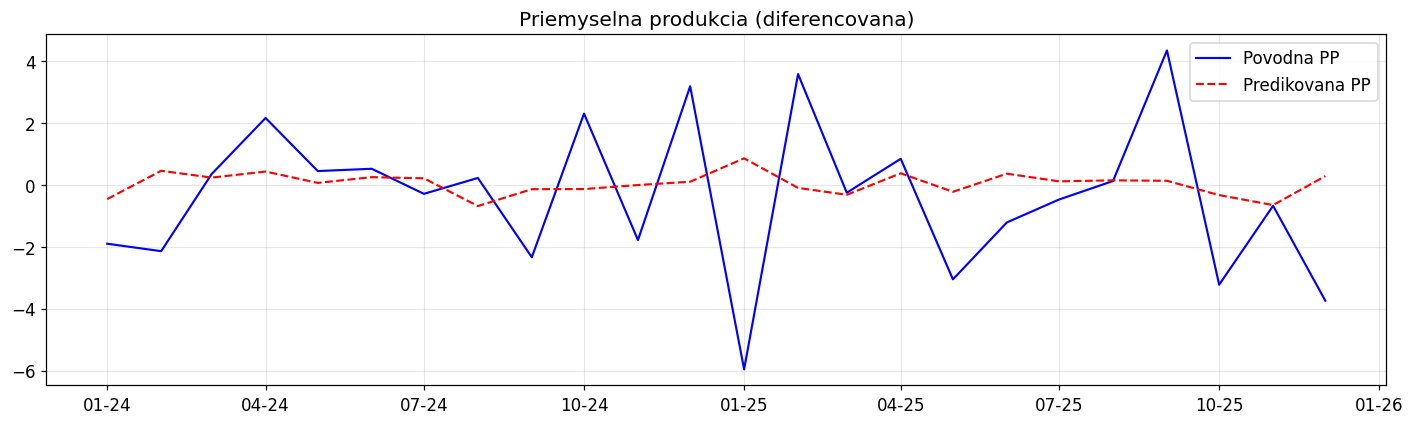

In [7]:
fig, ax = plt.subplots()
ax.plot(results.index, results["actual_diff"], color= "blue", linewidth = 1.4, label = "Povodna PP")
ax.plot(results.index, results["predicted_diff"], color= "red", linestyle='--', linewidth = 1.4, label = "Predikovana PP")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%y"))
ax.set_title("Priemyselna produkcia (diferencovana)")
ax.legend()
plt.tight_layout()
plt.show()

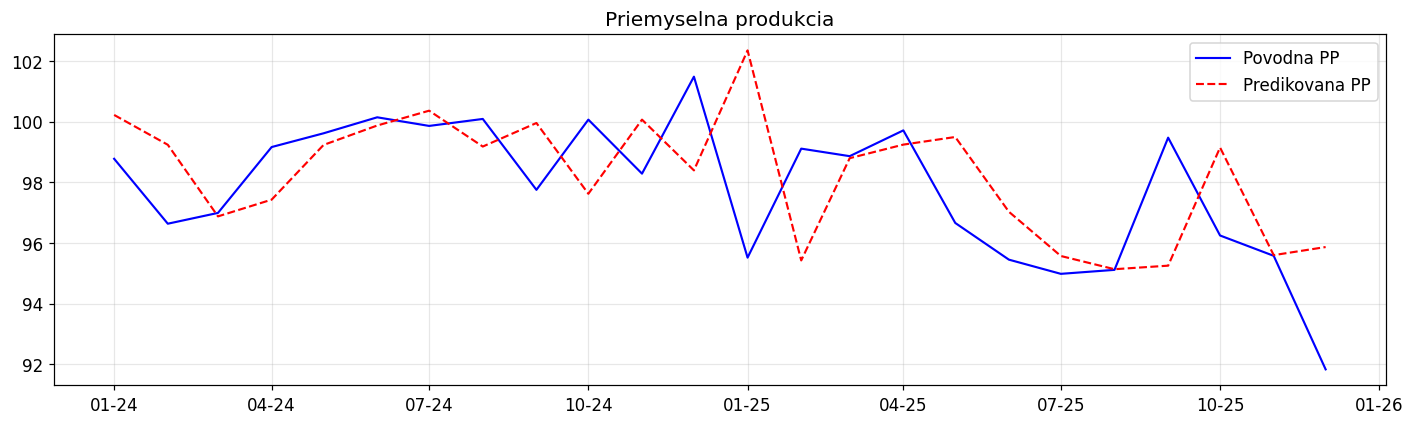

In [8]:
fig, ax = plt.subplots()
ax.plot(results.index, results["actual_level"], color= "blue", linewidth = 1.4, label = "Povodna PP")
ax.plot(results.index, results["predicted_level"], color= "red", linestyle='--', linewidth = 1.4, label = "Predikovana PP")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%y"))
ax.set_title("Priemyselna produkcia")
ax.legend()
plt.tight_layout()
plt.show()

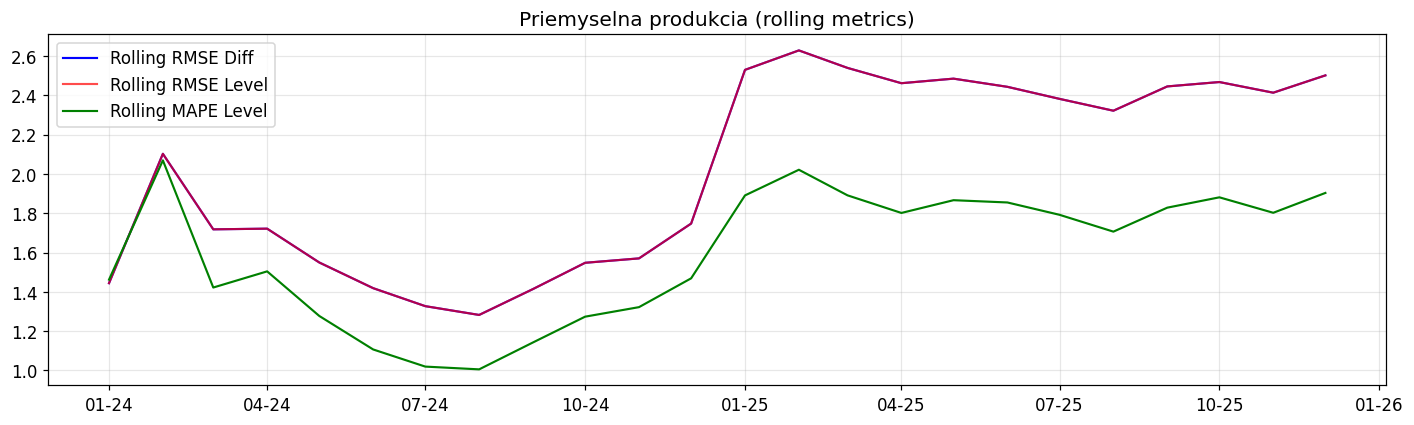

In [9]:
fig, ax = plt.subplots()
ax.plot(results.index, results["rolling_rmse_diff"], color= "blue", linewidth = 1.4, label = "Rolling RMSE Diff")
ax.plot(results.index, results["rolling_rmse_level"], color= "red", linewidth = 1.4, label = "Rolling RMSE Level", alpha = 0.7)
ax.plot(results.index, results["rolling_mape_level"], color= "green", linewidth = 1.4, label = "Rolling MAPE Level")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%y"))
ax.set_title("Priemyselna produkcia (rolling metrics)")
ax.legend()
plt.tight_layout()
plt.show()

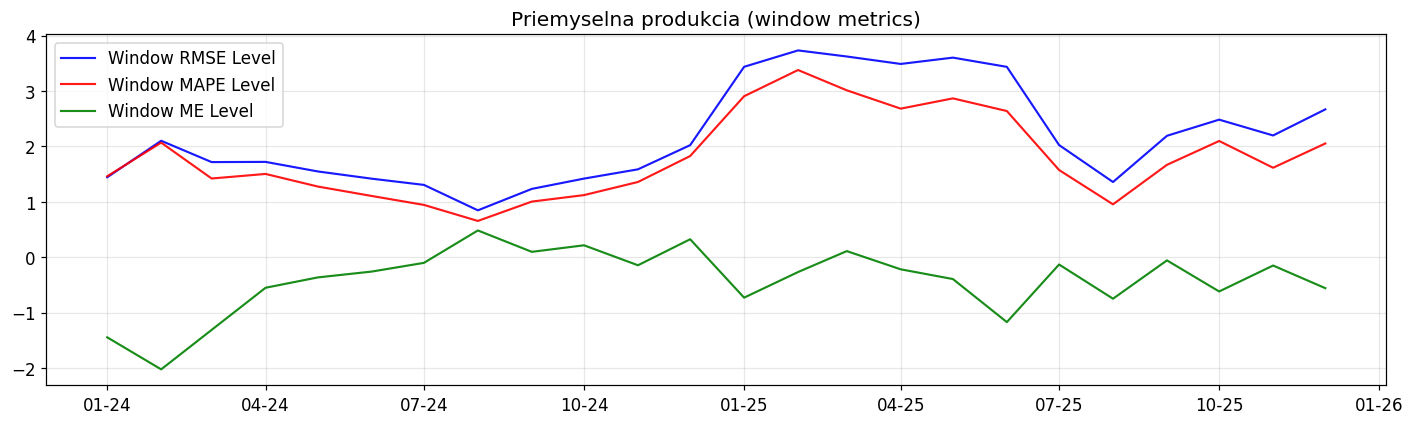

In [29]:
fig, ax = plt.subplots()
ax.plot(results.index, results["window6_rmse_level"], color= "blue", linewidth = 1.4, label = "Window RMSE Level", alpha = 0.9)
ax.plot(results.index, results["window6_mape_level"], color= "red", linewidth = 1.4, label = "Window MAPE Level", alpha = 0.9)
ax.plot(results.index, results["window6_me_level"], color= "green", linewidth = 1.4, label = "Window ME Level", alpha = 0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%y"))
ax.set_title("Priemyselna produkcia (window metrics)")
ax.legend()
plt.tight_layout()
plt.show()

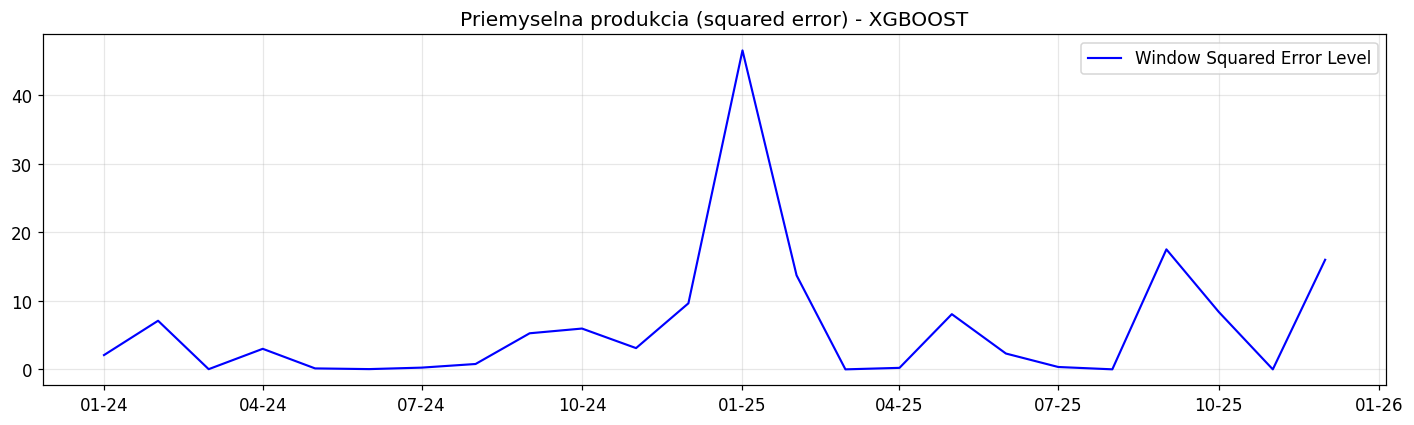

In [11]:
fig, ax = plt.subplots()
ax.plot(results.index, results["sq_error_level"], color= "blue", linewidth = 1.4, label = "Window Squared Error Level")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%y"))
ax.set_title("Priemyselna produkcia (squared error) - XGBOOST")
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
#shap
last_date = max(last_model.keys())
xgb_model = last_model[last_date]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap_summary = pd.DataFrame(shap_values, columns = X_test.columns, index = X_test.index)
mean_abs_shap = np.abs(shap_summary).mean().sort_values(ascending=False)
mean_abs_shap

expected_industry_production_lag1     0.090564
pp_sa_ca_jd_lag6                      0.057105
industry_confidence_sa_lag1           0.052587
vklady_nefinancne_podniky_lag1        0.049267
infl_cpi_lag1                         0.045374
trzby_priemysel_sa_lag1               0.039838
ipcv_priemysel_lag1                   0.038045
economic_sentiment_lag1               0.036228
trend                                 0.035651
oil_price_eur_lag1                    0.034567
expected_employment_lag1              0.029768
pp_sa_ca_jd_lag12                     0.025360
pp_sa_ca_jd_lag2                      0.020768
oil_europe_eur_lag1                   0.020700
current_total_demand_sa_lag1          0.020481
kurz_usd_eur_lag1                     0.019345
cdd_lag1                              0.017422
cpi_nsa_lag1                          0.016216
uvery_celkom_lag1                     0.014869
expected_product_prices_lag1          0.011523
oil_europe_usd_lag1                   0.009772
sadzba_3m_eur

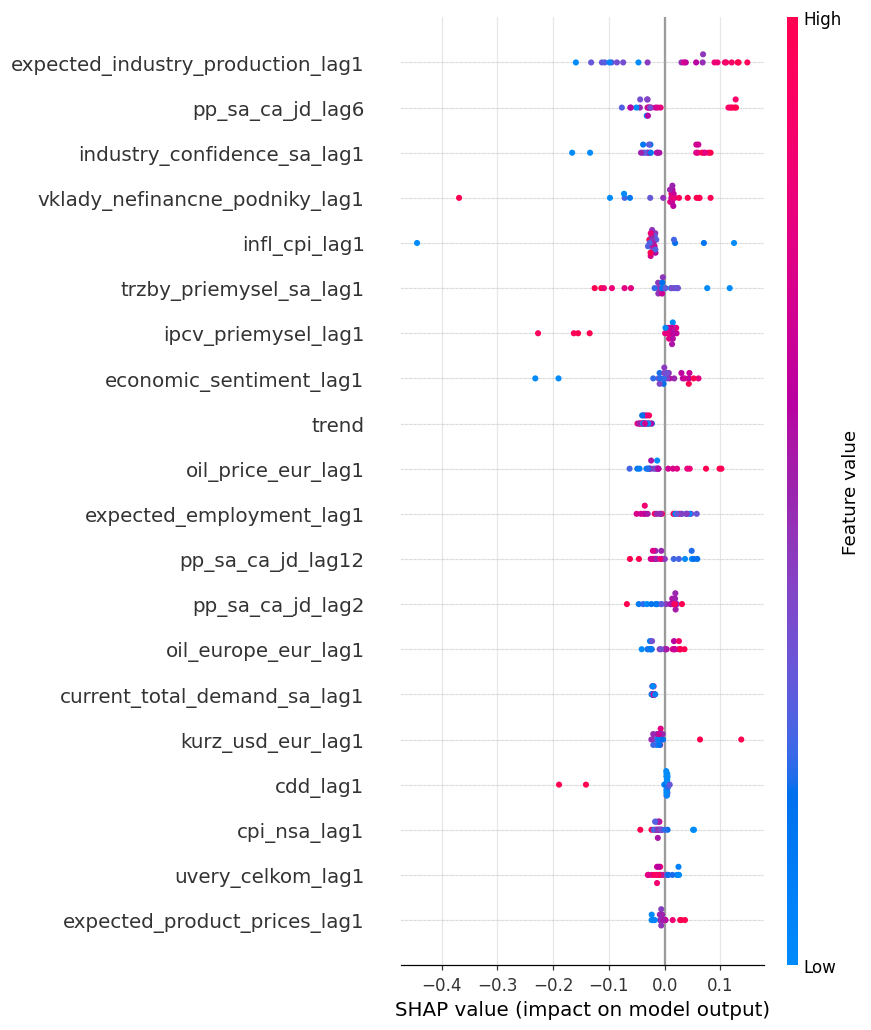

In [38]:
#graf ku shapu
shap.summary_plot(shap_values, X_test)

In [41]:
shap_rows = []

for forecast_date, xgb_model in last_model.items():

    X_one = X_test.loc[[forecast_date]].copy()

    explainer = shap.TreeExplainer(xgb_model)
    shap_one = explainer(X_one)

    for feature, value, contribution in zip(X_one.columns, X_one.iloc[0].values, shap_one.values[0]):
        shap_rows.append(
            {
                "forecast_date": forecast_date,
                "feature": feature,
                "feature_value": value,
                "shap_value": contribution,
                "abs_shap_value": abs(contribution),
            }
        )

shap_long = pd.DataFrame(shap_rows)
shap_long


,forecast_date,feature,feature_value,shap_value,abs_shap_value
0,2024-01-01,pp_sa_ca_jd_lag2,-2.366972,-0.068444,0.068444
1,2024-01-01,pp_sa_ca_jd_lag3,2.416140,0.086365,0.086365
2,2024-01-01,pp_sa_ca_jd_lag6,-5.675175,-0.024686,0.024686
3,2024-01-01,pp_sa_ca_jd_lag12,8.032883,-0.048333,0.048333
4,2024-01-01,cpi_nsa_lag1,-0.307200,0.124419,0.124419
...,...,...,...,...,...
275,2025-10-01,oil_europe_eur_lag1,-0.395206,0.001844,0.001844
276,2025-10-01,crisis_dummy_lag1,0.000000,0.000000,0.000000
277,2025-10-01,month,10.000000,0.004953,0.004953
278,2025-10-01,quarter,4.000000,0.000578,0.000578


In [42]:
shap_global = (
    shap_long
    .groupby("feature", as_index= False)
    .agg(
        mean_abs_shap = ("abs_shap_value", "mean"),
        mean_shap = ("shap_value", "mean"),
        median_abs_shap=("abs_shap_value", "median"),
    )
    .sort_values("mean_abs_shap", ascending=False)
)

print(shap_global.head(15).to_string(index=False))

                          feature  mean_abs_shap  mean_shap  median_abs_shap
   vklady_nefinancne_podniky_lag1       0.112437  -0.076634         0.050933
expected_industry_production_lag1       0.084333  -0.002662         0.102407
      industry_confidence_sa_lag1       0.073164   0.027092         0.073821
                 pp_sa_ca_jd_lag6       0.064649   0.027483         0.041347
                     cpi_nsa_lag1       0.048537   0.028352         0.016215
                            trend       0.039546  -0.039546         0.037208
                    infl_cpi_lag1       0.038988   0.022779         0.023102
          trzby_priemysel_sa_lag1       0.036610  -0.024220         0.014373
          economic_sentiment_lag1       0.034353   0.028487         0.018495
                pp_sa_ca_jd_lag12       0.031017  -0.001354         0.034622
                kurz_usd_eur_lag1       0.030037   0.008976         0.012557
               oil_price_eur_lag1       0.029027  -0.003528         0.023565

In [43]:
trees_df = extract_tree_structure(xgb_model)

In [44]:
# iba listove uzly (vahy) jedneho konkretneho stromu
tree_0_leaves = trees_df[(trees_df["Tree"] == 0) & (trees_df["Feature"] == "Leaf")]
print(tree_0_leaves[["Tree", "Node", "Gain", "Cover"]])

    Tree  Node      Gain  Cover
1      0     1 -0.028953    1.0
3      0     3  0.021409    2.0
8      0     8 -0.014278    2.0
10     0    10  0.017012    2.0
11     0    11 -0.003587   35.0
12     0    12  0.000451   84.0
13     0    13  0.003028   33.0
14     0    14 -0.001817    5.0


In [45]:
#najcastejsie pouzivane premenne na delenie
split_counts = (
    trees_df[trees_df["Feature"] != "Leaf"]
    .groupby("Feature")
    .size()
    .sort_values(ascending=False)
)
print(split_counts)

Feature
pp_sa_ca_jd_lag2                      391
pp_sa_ca_jd_lag6                      197
trzby_priemysel_sa_lag1               175
oil_price_eur_lag1                    167
expected_industry_production_lag1     166
pp_sa_ca_jd_lag3                      164
pp_sa_ca_jd_lag12                     162
vklady_nefinancne_podniky_lag1        152
export_celkovy_sa_lag1                147
infl_cpi_lag1                         143
industry_confidence_sa_lag1           134
cpi_nsa_lag1                          114
oil_europe_eur_lag1                   108
ipcv_priemysel_lag1                   107
current_total_demand_sa_lag1          102
economic_sentiment_lag1                85
kurz_usd_eur_lag1                      75
expected_employment_lag1               75
uvery_celkom_lag1                      69
cpi_sa_lag1                            62
sadzba_3m_euribor_lag1                 62
sh_prices_non_sa_lag1                  53
unem_prod_lag1                         52
hdd_lag1                  

In [46]:
#priemerny Gain pri deleni podla premennej
avg_gain_by_feature = (
    trees_df[trees_df["Feature"] != "Leaf"]
    .groupby("Feature")["Gain"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_gain_by_feature)

Feature
oil_europe_usd_lag1                   141.057732
current_total_demand_sa_lag1          132.054214
oil_europe_eur_lag1                   131.302451
foreign_demand_sa_lag1                119.300936
oil_price_eur_lag1                    117.448078
industry_confidence_sa_lag1            82.926111
trzby_priemysel_sa_lag1                82.679256
export_celkovy_sa_lag1                  81.14912
expected_industry_production_lag1      78.977637
economic_sentiment_lag1                78.558114
infl_cpi_lag1                          72.426558
vklady_nefinancne_podniky_lag1         68.483654
quarter                                 66.94513
pp_sa_ca_jd_lag2                       57.417842
cdd_lag1                                56.45673
kurz_usd_eur_lag1                      48.303244
expected_employment_lag1               45.889332
sh_prices_non_sa_lag1                  45.394454
finished_goods_inventories_sa_lag1     44.868886
trend                                  44.854282
month       

In [57]:
#kompletna struktura jedneho konkretneho stromu
last_tree = trees_df.iloc[-1, 0]
tree_last_full = trace_path_for_observation(trees_df, tree_index=last_tree)
print(tree_last_full)

      Node                         Feature     Split     Yes      No  \
7055     0             oil_europe_usd_lag1     -17.1   299-1   299-2   
7056     1                pp_sa_ca_jd_lag2 -2.223699   299-3   299-4   
7057     2                pp_sa_ca_jd_lag2  7.969917   299-5   299-6   
7058     3                            Leaf      <NA>    <NA>    <NA>   
7059     4                            Leaf      <NA>    <NA>    <NA>   
7060     5         trzby_priemysel_sa_lag1  451.0493   299-7   299-8   
7061     6               kurz_usd_eur_lag1     -0.01   299-9  299-10   
7062     7  vklady_nefinancne_podniky_lag1     540.0  299-11  299-12   
7063     8        expected_employment_lag1       3.2  299-13  299-14   
7064     9                            Leaf      <NA>    <NA>    <NA>   
7065    10                pp_sa_ca_jd_lag2  9.487995  299-15  299-16   
7066    11         trzby_priemysel_sa_lag1  -862.127  299-17  299-18   
7067    12                  unem_prod_lag1    0.0036  299-19  29

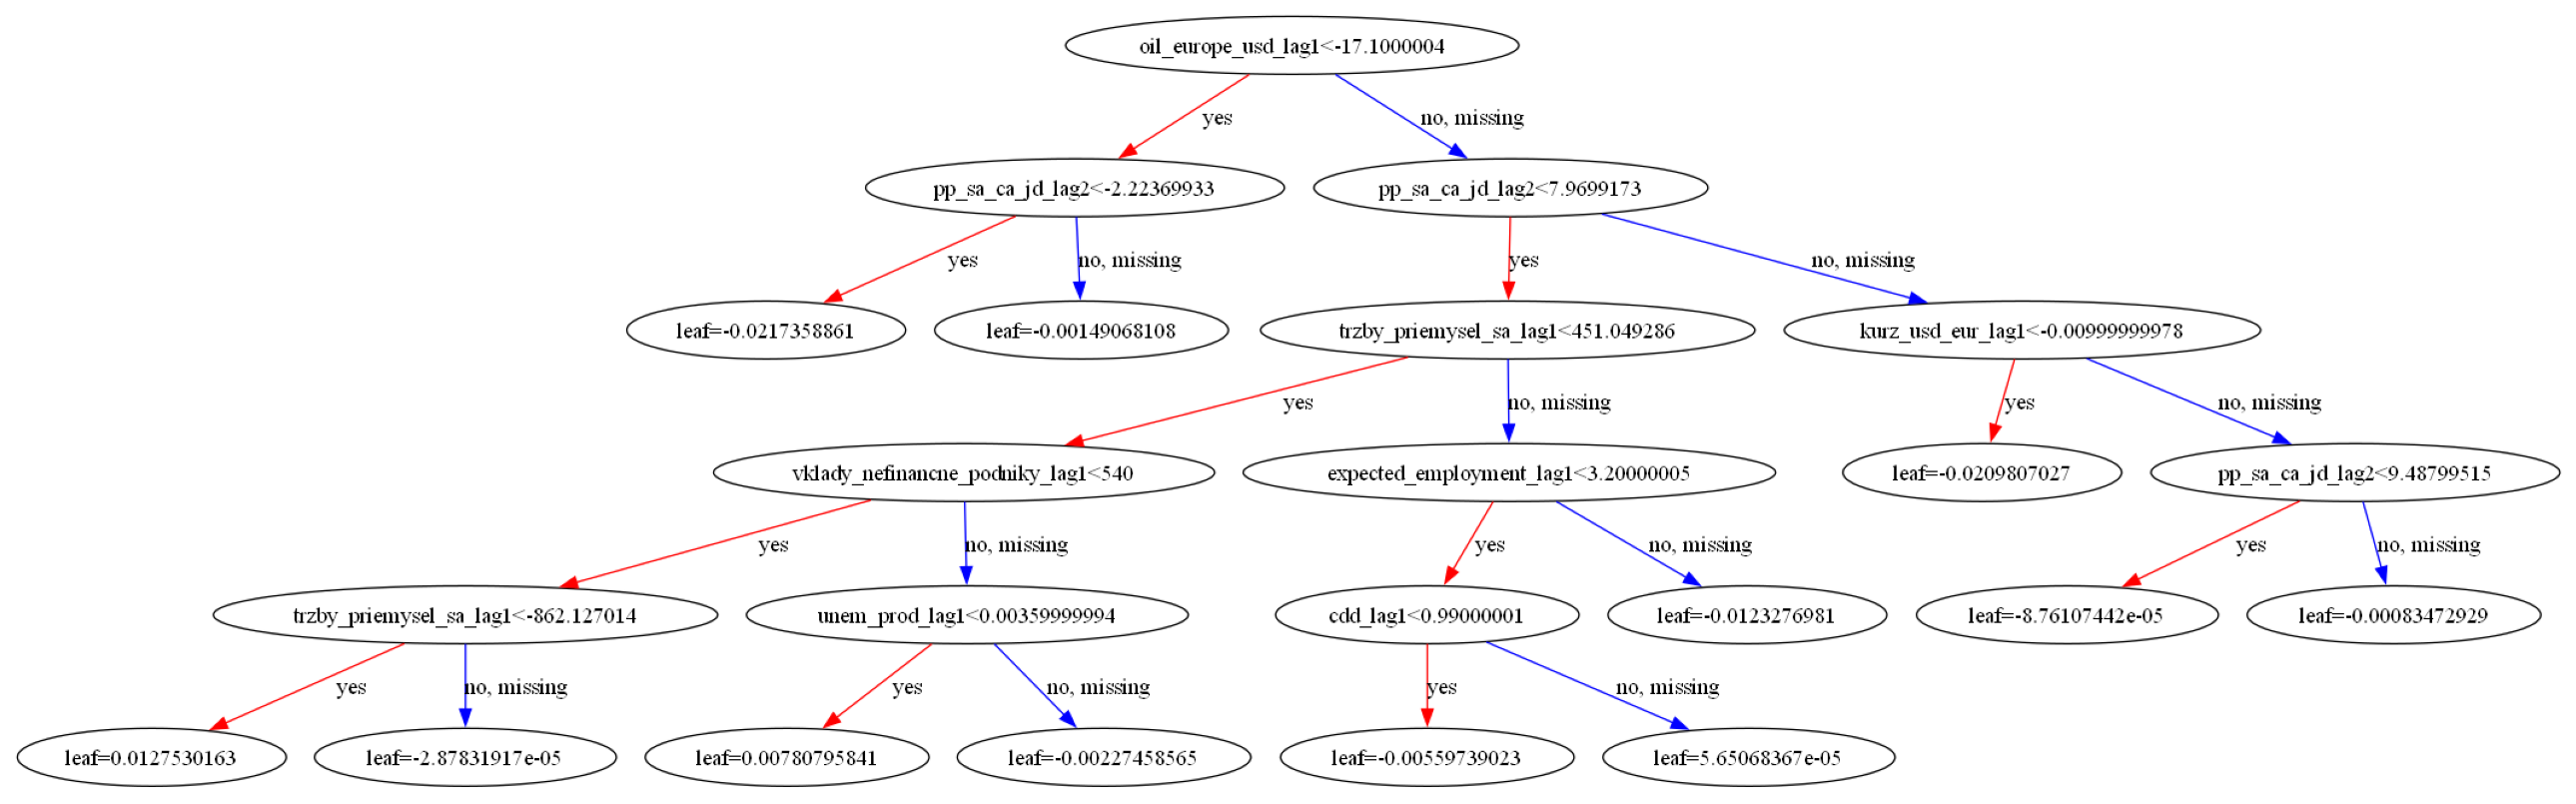

In [58]:
#graficke zobrazenie stromu
from xgboost import plot_tree
import matplotlib.pyplot as plt

plot_tree(xgb_model, num_trees=last_tree)
fig = plt.gcf()
fig.set_size_inches(30, 15)

In [59]:
#Pocet listov a vnutornych uzlov pre kazdy strom
tree_summary = trees_df.groupby("Tree").agg(
    n_nodes=("Node", "count"),
    n_leaves=("Feature", lambda x: (x == "Leaf").sum()),
).reset_index()

# pre binarny strom: n_splits = n_leaves - 1
tree_summary["n_splits"] = tree_summary["n_leaves"] - 1

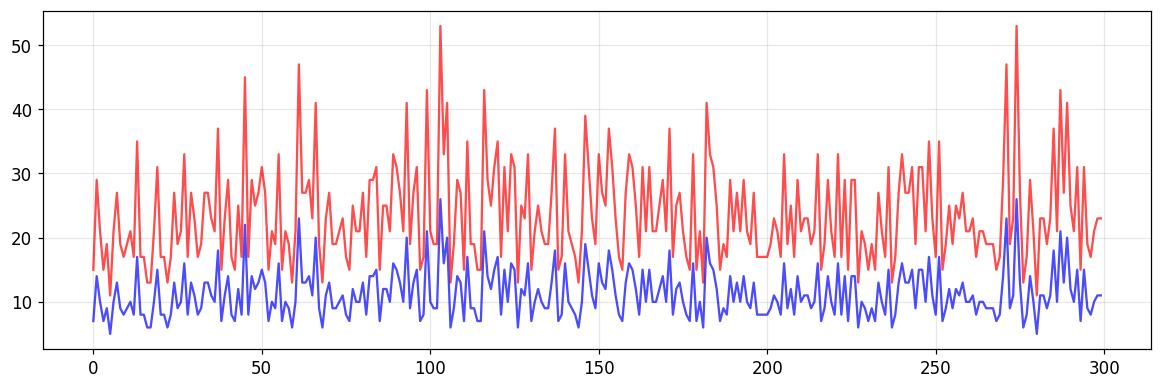

In [72]:
plt.plot(tree_summary["Tree"], tree_summary["n_nodes"], color = "red", alpha = 0.7)
plt.plot(tree_summary["Tree"], tree_summary["n_splits"], color = "blue", alpha = 0.7)

plt.show()

In [60]:
#Zakladna statistika - kolko stromov ma 0, 1, 2+ deleni
split_distribution = tree_summary["n_splits"].value_counts().sort_index()
print("Rozdelenie poctu deleni naprieč stromami:")
print(split_distribution)

n_trivial = (tree_summary["n_splits"] == 0).sum()
n_single_split = (tree_summary["n_splits"] > 1).sum()
n_multi_split = (tree_summary["n_splits"] > 10).sum()

print(f"\nStromy bez delenia (len 1 list):       {n_trivial}")
print(f"Stromy s viac ako 1 delenim (3+ listy):    {n_single_split}")
print(f"Stromy s viac ako 10 delenim (21+ listy): {n_multi_split}")


Rozdelenie poctu deleni naprieč stromami:
n_splits
5      2
6     12
7     25
8     38
9     37
10    44
11    21
12    17
13    27
14    18
15    20
16    15
17     5
18     5
19     1
20     5
21     3
22     1
23     2
26     2
Name: count, dtype: int64

Stromy bez delenia (len 1 list):       0
Stromy s viac ako 1 delenim (3+ listy):    300
Stromy s viac ako 10 delenim (21+ listy): 142


In [74]:
#ktore konkretne stromy maju viac ako 1 delenie
trees_with_multi_splits = tree_summary[tree_summary["n_splits"] > 1].sort_values(
    "n_splits", ascending=False
)
print("\nStromy s viac ako 1 delenim (zoradene podla poctu deleni):")
print(trees_with_multi_splits)


Stromy s viac ako 1 delenim (zoradene podla poctu deleni):
     Tree  n_nodes  n_leaves  n_splits
274   274       53        27        26
103   103       53        27        26
61     61       47        24        23
271   271       47        24        23
45     45       45        23        22
..    ...      ...       ...       ...
181   181       13         7         6
237   237       13         7         6
22     22       13         7         6
280   280       11         6         5
5       5       11         6         5

[300 rows x 4 columns]


In [75]:
# Priemerny pocet deleni cez cely ansambel - rychly diagnosticky ukazovatel
avg_splits = tree_summary["n_splits"].mean()
pct_trivial = (n_trivial / len(tree_summary)) * 100
print(f"\nPriemerny pocet deleni na strom: {avg_splits:.2f}")
print(f"Podiel trivialnych (nerozdelenych) stromov: {pct_trivial:.1f}%")


Priemerny pocet deleni na strom: 11.30
Podiel trivialnych (nerozdelenych) stromov: 0.0%
